In [5]:
# 01 Data Audit

This notebook audits the raw supermarket price dataset before any cleaning.

The aims are to:

1. Confirm the raw archive is readable.
2. Profile all five supermarket files.
3. Report column names, data types, missing values, row counts, date ranges, and unique counts.
4. Prepare evidence for the later data-quality report.

SyntaxError: invalid syntax (2033636011.py, line 3)

In [6]:
from pathlib import Path
import zipfile

import pandas as pd
import numpy as np

In [7]:
PROJECT_ROOT = Path.cwd().parent

RAW_ZIP = PROJECT_ROOT / "data" / "raw" / "archive.zip"
RESULTS_DIR = PROJECT_ROOT / "results" / "data_audit"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw zip exists:", RAW_ZIP.exists())
print("Raw zip path:", RAW_ZIP)

Project root: /Users/charan/Documents/supermarket-price-direction
Raw zip exists: True
Raw zip path: /Users/charan/Documents/supermarket-price-direction/data/raw/archive.zip


In [8]:
PROJECT_ROOT = Path.cwd().parent

RAW_ZIP = PROJECT_ROOT / "data" / "raw" / "archive.zip"
RESULTS_DIR = PROJECT_ROOT / "results" / "data_audit"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw zip exists:", RAW_ZIP.exists())
print("Raw zip path:", RAW_ZIP)

Project root: /Users/charan/Documents/supermarket-price-direction
Raw zip exists: True
Raw zip path: /Users/charan/Documents/supermarket-price-direction/data/raw/archive.zip


In [9]:
with zipfile.ZipFile(RAW_ZIP, "r") as z:
    zip_files = z.namelist()

csv_files = [
    f for f in zip_files
    if f.endswith(".csv") and not f.startswith("__MACOSX")
]

csv_files

['All_Data_ASDA.csv',
 'All_Data_Aldi.csv',
 'All_Data_Morrisons.csv',
 'All_Data_Sains.csv',
 'All_Data_Tesco.csv']

In [10]:
dataframes = {}

with zipfile.ZipFile(RAW_ZIP, "r") as z:
    for file in csv_files:
        retailer_name = Path(file).stem.replace("All_Data_", "")
        dataframes[retailer_name] = pd.read_csv(z.open(file))

print("Loaded retailers:")
print(list(dataframes.keys()))

for retailer, df in dataframes.items():
    print(retailer, df.shape)

/var/folders/fv/fwvgzy3s0sxcnl40361wnyt00000gn/T/ipykernel_51357/353376516.py:6: DtypeWarning: Columns (0: own_brand) have mixed types. Specify dtype option on import or set low_memory=False.
  dataframes[retailer_name] = pd.read_csv(z.open(file))


Loaded retailers:
['ASDA', 'Aldi', 'Morrisons', 'Sains', 'Tesco']
ASDA (2456414, 8)
Aldi (464863, 8)
Morrisons (1794065, 8)
Sains (2600289, 8)
Tesco (2213611, 8)


In [11]:
for retailer, df in dataframes.items():
    print("\n" + "="*60)
    print(retailer)
    print("="*60)
    print(df.columns.tolist())


ASDA
['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']

Aldi
['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']

Morrisons
['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']

Sains
['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']

Tesco
['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']


In [12]:
combined_raw = []

for retailer, df in dataframes.items():
    temp = df.copy()
    temp["retailer_file"] = retailer
    combined_raw.append(temp)

raw = pd.concat(combined_raw, ignore_index=True)

print("Combined raw shape:", raw.shape)
raw.head()

Combined raw shape: (9529242, 9)


,supermarket,prices_(£),prices_unit_(£),unit,names,date,category,own_brand,retailer_file
0,ASDA,4.75,19.8,kg,Tassimo Cadbury Hot Chocolate Pods x 8,20240413,drinks,False,ASDA
1,ASDA,2.00,26.7,kg,Taylors of Harrogate Hot Lava Java Coffee Bags,20240413,drinks,False,ASDA
2,ASDA,5.00,20.8,kg,Tassimo Limited Edition Cadbury Orange Hot Cho...,20240413,drinks,False,ASDA
3,ASDA,3.50,15.4,kg,ASDA Extra Special Brazilian Ground Coffee,20240413,drinks,True,ASDA
4,ASDA,3.50,15.4,kg,ASDA Extra Special Espresso Coffee Beans,20240413,drinks,True,ASDA


In [13]:
dataset_summary = []

for retailer, df in dataframes.items():
    dataset_summary.append({
        "retailer": retailer,
        "rows": len(df),
        "columns": df.shape[1],
        "column_names": ", ".join(df.columns)
    })

dataset_summary = pd.DataFrame(dataset_summary)
dataset_summary

,retailer,rows,columns,column_names
0,ASDA,2456414,8,"supermarket, prices_(£), prices_unit_(£), unit..."
1,Aldi,464863,8,"supermarket, prices_(£), prices_unit_(£), unit..."
2,Morrisons,1794065,8,"supermarket, prices_(£), prices_unit_(£), unit..."
3,Sains,2600289,8,"supermarket, prices_(£), prices_unit_(£), unit..."
4,Tesco,2213611,8,"supermarket, prices_(£), prices_unit_(£), unit..."


In [14]:
dataset_summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)

print("Saved:", RESULTS_DIR / "dataset_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/dataset_summary.csv


In [15]:
column_profile = []

for retailer, df in dataframes.items():
    for col in df.columns:
        column_profile.append({
            "retailer": retailer,
            "column": col,
            "dtype": str(df[col].dtype),
            "rows": len(df),
            "missing_count": df[col].isna().sum(),
            "missing_pct": round(df[col].isna().mean() * 100, 4),
            "unique_count": df[col].nunique(dropna=True)
        })

column_profile = pd.DataFrame(column_profile)
column_profile

,retailer,column,dtype,rows,missing_count,missing_pct,unique_count
0,ASDA,supermarket,str,2456414,0,0.0000,1
1,ASDA,prices_(£),float64,2456414,7,0.0003,826
2,ASDA,prices_unit_(£),float64,2456414,199,0.0081,2819
3,ASDA,unit,str,2456414,199,0.0081,4
4,ASDA,names,str,2456414,26,0.0011,32660
5,ASDA,date,int64,2456414,0,0.0000,92
6,ASDA,category,str,2456414,0,0.0000,11
7,ASDA,own_brand,object,2456414,26,0.0011,2
8,Aldi,supermarket,str,464863,0,0.0000,1
9,Aldi,prices_(£),float64,464863,0,0.0000,272


In [16]:
column_profile.to_csv(RESULTS_DIR / "column_profile.csv", index=False)

print("Saved:", RESULTS_DIR / "column_profile.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/column_profile.csv


In [17]:
raw["date_parsed"] = pd.to_datetime(raw["date"].astype(str), format="%Y%m%d", errors="coerce")

print("Missing parsed dates:", raw["date_parsed"].isna().sum())
raw[["date", "date_parsed"]].head()

Missing parsed dates: 0


,date,date_parsed
0,20240413,2024-04-13
1,20240413,2024-04-13
2,20240413,2024-04-13
3,20240413,2024-04-13
4,20240413,2024-04-13


In [18]:
date_coverage = (
    raw.groupby("retailer_file")
    .agg(
        rows=("date_parsed", "size"),
        min_date=("date_parsed", "min"),
        max_date=("date_parsed", "max"),
        observed_dates=("date_parsed", "nunique")
    )
    .reset_index()
)

date_coverage["calendar_days_in_range"] = (
    date_coverage["max_date"] - date_coverage["min_date"]
).dt.days + 1

date_coverage["missing_capture_days"] = (
    date_coverage["calendar_days_in_range"] - date_coverage["observed_dates"]
)

date_coverage

,retailer_file,rows,min_date,max_date,observed_dates,calendar_days_in_range,missing_capture_days
0,ASDA,2456414,2024-01-09,2024-04-13,92,96,4
1,Aldi,464863,2024-01-09,2024-04-13,92,96,4
2,Morrisons,1794065,2024-01-09,2024-04-13,92,96,4
3,Sains,2600289,2024-01-09,2024-04-13,92,96,4
4,Tesco,2213611,2024-01-09,2024-04-13,91,96,5


In [19]:
date_coverage.to_csv(RESULTS_DIR / "date_coverage_by_retailer.csv", index=False)

print("Saved:", RESULTS_DIR / "date_coverage_by_retailer.csv")


Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/date_coverage_by_retailer.csv


In [20]:
missing_dates_by_retailer = []

for retailer, group in raw.groupby("retailer_file"):
    observed = set(group["date_parsed"].dropna().dt.date.unique())
    full_range = pd.date_range(
        group["date_parsed"].min(),
        group["date_parsed"].max(),
        freq="D"
    )

    for date in full_range:
        if date.date() not in observed:
            missing_dates_by_retailer.append({
                "retailer": retailer,
                "missing_date": date.date()
            })

missing_dates_by_retailer = pd.DataFrame(missing_dates_by_retailer)
missing_dates_by_retailer

,retailer,missing_date
0,ASDA,2024-02-02
1,ASDA,2024-02-03
2,ASDA,2024-03-14
3,ASDA,2024-03-23
4,Aldi,2024-02-02
5,Aldi,2024-02-03
6,Aldi,2024-03-14
7,Aldi,2024-03-23
8,Morrisons,2024-02-02
9,Morrisons,2024-02-03


In [21]:
missing_dates_by_retailer.to_csv(
    RESULTS_DIR / "missing_capture_dates_by_retailer.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "missing_capture_dates_by_retailer.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/missing_capture_dates_by_retailer.csv


In [22]:
unique_counts = (
    raw.groupby("retailer_file")
    .agg(
        rows=("names", "size"),
        unique_products=("names", "nunique"),
        unique_categories=("category", "nunique"),
        unique_price_values=("prices_(£)", "nunique"),
        unique_unit_price_values=("prices_unit_(£)", "nunique"),
        unique_units=("unit", "nunique")
    )
    .reset_index()
)

unique_counts

,retailer_file,rows,unique_products,unique_categories,unique_price_values,unique_unit_price_values,unique_units
0,ASDA,2456414,32660,11,826,2819,4
1,Aldi,464863,7262,10,272,1156,4
2,Morrisons,1794065,26187,11,800,2507,4
3,Sains,2600289,33886,11,846,3014,4
4,Tesco,2213611,30637,10,951,3104,4


In [23]:
unique_counts.to_csv(RESULTS_DIR / "unique_counts_by_retailer.csv", index=False)

print("Saved:", RESULTS_DIR / "unique_counts_by_retailer.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/unique_counts_by_retailer.csv


In [24]:
price_profile = (
    raw.groupby("retailer_file")
    .agg(
        rows=("prices_(£)", "size"),
        price_missing=("prices_(£)", lambda s: s.isna().sum()),
        price_min=("prices_(£)", "min"),
        price_q01=("prices_(£)", lambda s: s.quantile(0.01)),
        price_median=("prices_(£)", "median"),
        price_mean=("prices_(£)", "mean"),
        price_q99=("prices_(£)", lambda s: s.quantile(0.99)),
        price_max=("prices_(£)", "max"),
        unit_price_missing=("prices_unit_(£)", lambda s: s.isna().sum()),
        unit_price_min=("prices_unit_(£)", "min"),
        unit_price_q01=("prices_unit_(£)", lambda s: s.quantile(0.01)),
        unit_price_median=("prices_unit_(£)", "median"),
        unit_price_mean=("prices_unit_(£)", "mean"),
        unit_price_q99=("prices_unit_(£)", lambda s: s.quantile(0.99)),
        unit_price_max=("prices_unit_(£)", "max")
    )
    .reset_index()
)

price_profile

,retailer_file,rows,price_missing,price_min,price_q01,price_median,price_mean,price_q99,price_max,unit_price_missing,unit_price_min,unit_price_q01,unit_price_median,unit_price_mean,unit_price_q99,unit_price_max
0,ASDA,2456414,7,0.05,0.52,3.00,5.757565,40.00,479.99,199,0.0,0.05,7.5,74.281058,1238.00,99778.0
1,Aldi,464863,0,0.01,0.39,1.59,2.216073,13.49,383.00,4,0.0,0.01,5.3,7.993101,36.80,2343.8
2,Morrisons,1794065,0,0.20,0.65,2.80,4.894816,31.00,300.00,110,0.0,0.06,7.4,26.181018,400.00,11225.0
3,Sains,2600289,0,0.01,0.60,3.00,5.464081,33.35,190.00,209,0.0,0.06,8.0,48.262480,648.30,40000.0
4,Tesco,2213611,0,0.00,0.55,3.00,5.283200,34.00,421.05,2,0.0,0.04,8.0,36.428052,706.25,150000.0


In [25]:
price_profile.to_csv(RESULTS_DIR / "price_profile_by_retailer.csv", index=False)

print("Saved:", RESULTS_DIR / "price_profile_by_retailer.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/price_profile_by_retailer.csv


In [26]:
duplicate_key_summary = []

for retailer, df in dataframes.items():
    key_cols = ["names", "supermarket", "date"]

    duplicated_mask = df.duplicated(subset=key_cols, keep=False)
    duplicated_rows = duplicated_mask.sum()

    duplicate_groups = (
        df.loc[duplicated_mask]
        .groupby(key_cols)
        .size()
        .reset_index(name="duplicate_count")
        .sort_values("duplicate_count", ascending=False)
    )

    duplicate_key_summary.append({
        "retailer": retailer,
        "rows": len(df),
        "duplicated_rows": duplicated_rows,
        "duplicated_rows_pct": round(duplicated_rows / len(df) * 100, 4),
        "duplicate_key_groups": len(duplicate_groups)
    })

duplicate_key_summary = pd.DataFrame(duplicate_key_summary)
duplicate_key_summary

,retailer,rows,duplicated_rows,duplicated_rows_pct,duplicate_key_groups
0,ASDA,2456414,4,0.0002,2
1,Aldi,464863,0,0.0000,0
2,Morrisons,1794065,0,0.0000,0
3,Sains,2600289,0,0.0000,0
4,Tesco,2213611,47656,2.1529,23828


In [27]:
duplicate_key_summary.to_csv(
    RESULTS_DIR / "hazard_duplicate_key_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_duplicate_key_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_duplicate_key_summary.csv


In [28]:
duplicate_key_examples = []

for retailer, df in dataframes.items():
    key_cols = ["names", "supermarket", "date"]

    duplicated_mask = df.duplicated(subset=key_cols, keep=False)

    examples = (
        df.loc[duplicated_mask]
        .groupby(key_cols)
        .size()
        .reset_index(name="duplicate_count")
        .sort_values("duplicate_count", ascending=False)
        .head(20)
    )

    examples["retailer_file"] = retailer
    duplicate_key_examples.append(examples)

duplicate_key_examples = pd.concat(duplicate_key_examples, ignore_index=True)
duplicate_key_examples

,names,supermarket,date,duplicate_count,retailer_file
0,Palmer's Shea Formula Raw Shea Body Lotion,ASDA,20240413,2,ASDA
1,Whiskas 1+ Tuna Adult Dry Cat Food,ASDA,20240413,2,ASDA
2,1 Marigold Extra Life Gloves Kitchen Large,Tesco,20240115,2,Tesco
3,TESCO NATURAL SEERSUCKER DUVET SET DOUBLE,Tesco,20240115,2,Tesco
4,TESCO RED POTATOES 2KG,Tesco,20240115,2,Tesco
5,TESCO PLANT CHEF FISH-FREE GOUJONS 250G,Tesco,20240115,2,Tesco
6,TESCO PLANT CHEF CRISPY NO-CHICKEN NUGGETS 180G,Tesco,20240115,2,Tesco
7,TESCO PLANT CHEF 2 SOUTHERN FRIED FILLETS 230G,Tesco,20240115,2,Tesco
8,TESCO PLANT CHEF 2 NO-CHICKEN GARLIC KIEVS 270G,Tesco,20240115,2,Tesco
9,TESCO PLANT CHEF 2 MEAT FREE SOUTHERN FRIED FI...,Tesco,20240115,2,Tesco


In [29]:
duplicate_key_examples.to_csv(
    RESULTS_DIR / "hazard_duplicate_key_examples.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_duplicate_key_examples.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_duplicate_key_examples.csv


In [30]:
price_hazard_summary = []

for retailer, df in dataframes.items():
    price = df["prices_(£)"]
    unit_price = df["prices_unit_(£)"]

    price_zero_or_negative = (price <= 0).sum()
    unit_price_zero_or_negative = (unit_price <= 0).sum()

    price_extreme = (price > price.quantile(0.99)).sum()
    unit_price_extreme = (unit_price > unit_price.quantile(0.99)).sum()

    price_missing = price.isna().sum()
    unit_price_missing = unit_price.isna().sum()

    any_implausible = (
        price.isna()
        | unit_price.isna()
        | (price <= 0)
        | (unit_price <= 0)
        | (price > price.quantile(0.99))
        | (unit_price > unit_price.quantile(0.99))
    )

    price_hazard_summary.append({
        "retailer": retailer,
        "rows": len(df),
        "price_missing": price_missing,
        "price_zero_or_negative": price_zero_or_negative,
        "price_above_99th_pct": price_extreme,
        "unit_price_missing": unit_price_missing,
        "unit_price_zero_or_negative": unit_price_zero_or_negative,
        "unit_price_above_99th_pct": unit_price_extreme,
        "rows_with_any_price_hazard": any_implausible.sum(),
        "rows_with_any_price_hazard_pct": round(any_implausible.mean() * 100, 4)
    })

price_hazard_summary = pd.DataFrame(price_hazard_summary)
price_hazard_summary

,retailer,rows,price_missing,price_zero_or_negative,price_above_99th_pct,unit_price_missing,unit_price_zero_or_negative,unit_price_above_99th_pct,rows_with_any_price_hazard,rows_with_any_price_hazard_pct
0,ASDA,2456414,7,0,21039,199,1136,24503,46877,1.9084
1,Aldi,464863,0,0,4489,4,2093,4446,11028,2.3723
2,Morrisons,1794065,0,0,17736,110,764,17752,34410,1.9180
3,Sains,2600289,0,0,25985,209,3809,25965,53794,2.0688
4,Tesco,2213611,0,3,21117,2,4794,22037,46398,2.0960


In [31]:
price_hazard_summary.to_csv(
    RESULTS_DIR / "hazard_implausible_price_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_implausible_price_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_implausible_price_summary.csv


In [32]:
capture_gap_hazard_summary = (
    missing_dates_by_retailer
    .groupby("retailer")
    .agg(missing_capture_days=("missing_date", "count"))
    .reset_index()
)

capture_gap_hazard_summary = capture_gap_hazard_summary.merge(
    date_coverage[["retailer_file", "calendar_days_in_range", "observed_dates"]],
    left_on="retailer",
    right_on="retailer_file",
    how="left"
).drop(columns=["retailer_file"])

capture_gap_hazard_summary["missing_capture_days_pct"] = (
    capture_gap_hazard_summary["missing_capture_days"]
    / capture_gap_hazard_summary["calendar_days_in_range"]
    * 100
).round(4)

capture_gap_hazard_summary

,retailer,missing_capture_days,calendar_days_in_range,observed_dates,missing_capture_days_pct
0,ASDA,4,96,92,4.1667
1,Aldi,4,96,92,4.1667
2,Morrisons,4,96,92,4.1667
3,Sains,4,96,92,4.1667
4,Tesco,5,96,91,5.2083


In [33]:
capture_gap_hazard_summary.to_csv(
    RESULTS_DIR / "hazard_capture_gap_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_capture_gap_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_capture_gap_summary.csv


In [35]:
duplicate_key_summary

,retailer,rows,duplicated_rows,duplicated_rows_pct,duplicate_key_groups
0,ASDA,2456414,4,0.0002,2
1,Aldi,464863,0,0.0000,0
2,Morrisons,1794065,0,0.0000,0
3,Sains,2600289,0,0.0000,0
4,Tesco,2213611,47656,2.1529,23828


In [37]:
import re

def normalise_name_for_audit(name):
    if pd.isna(name):
        return np.nan
    
    name = str(name).lower()
    name = re.sub(r"[^a-z0-9]+", " ", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

raw["name_normalised_audit"] = raw["names"].apply(normalise_name_for_audit)

name_spelling_groups = (
    raw.dropna(subset=["names", "name_normalised_audit"])
    .groupby(["retailer_file", "name_normalised_audit"])
    .agg(
        raw_name_variants=("names", "nunique"),
        rows=("names", "size")
    )
    .reset_index()
)

inconsistent_name_groups = name_spelling_groups[
    name_spelling_groups["raw_name_variants"] > 1
].copy()

spelling_hazard_summary = (
    inconsistent_name_groups
    .groupby("retailer_file")
    .agg(
        inconsistent_normalised_name_groups=("name_normalised_audit", "count"),
        affected_rows=("rows", "sum")
    )
    .reset_index()
)

retailer_rows = raw.groupby("retailer_file").size().reset_index(name="total_rows")

spelling_hazard_summary = spelling_hazard_summary.merge(
    retailer_rows,
    on="retailer_file",
    how="right"
).fillna({
    "inconsistent_normalised_name_groups": 0,
    "affected_rows": 0
})

spelling_hazard_summary["affected_rows_pct"] = (
    spelling_hazard_summary["affected_rows"]
    / spelling_hazard_summary["total_rows"]
    * 100
).round(4)

spelling_hazard_summary

,retailer_file,inconsistent_normalised_name_groups,affected_rows,total_rows,affected_rows_pct
0,ASDA,46,6007,2456414,0.2445
1,Aldi,6,605,464863,0.1301
2,Morrisons,90,11008,1794065,0.6136
3,Sains,156,11912,2600289,0.4581
4,Tesco,39,3393,2213611,0.1533


In [38]:
spelling_hazard_summary.to_csv(
    RESULTS_DIR / "hazard_name_spelling_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_name_spelling_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_name_spelling_summary.csv


In [39]:
name_spelling_examples = []

for retailer, group in raw.groupby("retailer_file"):
    temp = (
        group.dropna(subset=["names", "name_normalised_audit"])
        .groupby("name_normalised_audit")
        .agg(
            raw_name_variants=("names", "nunique"),
            example_names=("names", lambda s: " | ".join(sorted(s.dropna().unique())[:10])),
            rows=("names", "size")
        )
        .reset_index()
    )
    
    temp = temp[temp["raw_name_variants"] > 1]
    temp["retailer_file"] = retailer
    
    name_spelling_examples.append(
        temp.sort_values(["raw_name_variants", "rows"], ascending=False).head(20)
    )

name_spelling_examples = pd.concat(name_spelling_examples, ignore_index=True)
name_spelling_examples

,name_normalised_audit,raw_name_variants,example_names,rows,retailer_file
0,always discreet incontinence pads long for sen...,2,Always Discreet Incontinence Pads Long for Se...,184,ASDA
1,asda super non applicator tampons,2,ASDA Super Non-Applicator Tampons | ASDA Super...,184,ASDA
2,gold leaf jps quality blend tobacco includes c...,2,Gold Leaf JPS Quality Blend Tobacco Includes C...,184,ASDA
3,lenor unstoppables in wash scent booster fresh,2,Lenor Unstoppables In-Wash Scent Booster Fresh...,182,ASDA
4,asda chow mein stir fry sauce,2,ASDA Chow Mein Stir Fry Sauce | ASDA Chow Mein...,180,ASDA
...,...,...,...,...,...
81,tesco green frill duvet set king size,2,TESCO GREEN FRILL DUVET SET KING SIZE | Tesco ...,87,Tesco
82,tesco breaded chicken goujons 540g,2,Tesco Breaded Chicken Goujons 540G | Tesco Bre...,85,Tesco
83,tesco raspberry trifle 600g,2,Tesco Raspberry Trifle 600G | Tesco Raspberry ...,85,Tesco
84,tesco southern fried chicken thighs drumsticks...,2,Tesco Southern Fried Chicken Thighs & Drumstic...,85,Tesco


In [40]:
name_spelling_examples.to_csv(
    RESULTS_DIR / "hazard_name_spelling_examples.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_name_spelling_examples.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_name_spelling_examples.csv


In [41]:
spelling_hazard_summary.to_csv(
    RESULTS_DIR / "hazard_name_spelling_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "hazard_name_spelling_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/hazard_name_spelling_summary.csv


In [42]:
import matplotlib.pyplot as plt

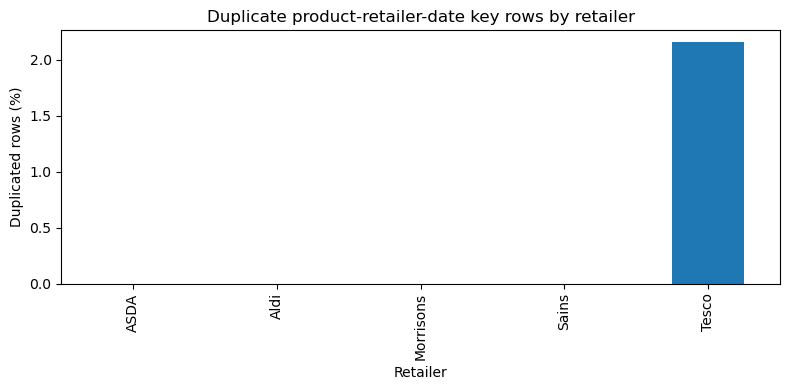

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/figure_hazard_duplicate_keys.png


In [43]:
fig, ax = plt.subplots(figsize=(8, 4))

duplicate_key_summary.plot(
    x="retailer",
    y="duplicated_rows_pct",
    kind="bar",
    legend=False,
    ax=ax
)

ax.set_title("Duplicate product-retailer-date key rows by retailer")
ax.set_xlabel("Retailer")
ax.set_ylabel("Duplicated rows (%)")

plt.tight_layout()

fig_path = RESULTS_DIR / "figure_hazard_duplicate_keys.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

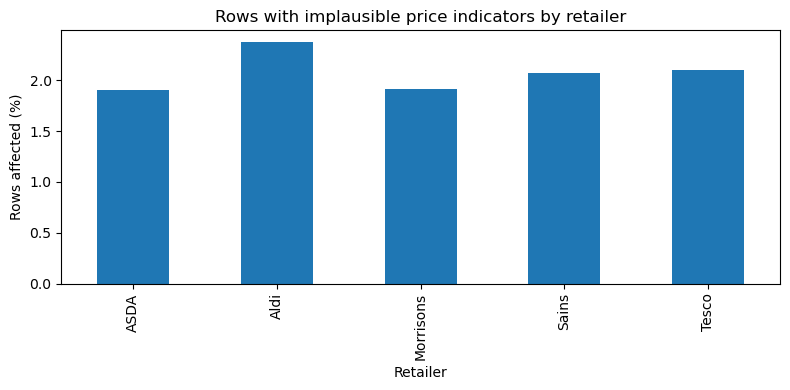

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/figure_hazard_implausible_prices.png


In [44]:
fig, ax = plt.subplots(figsize=(8, 4))

price_hazard_summary.plot(
    x="retailer",
    y="rows_with_any_price_hazard_pct",
    kind="bar",
    legend=False,
    ax=ax
)

ax.set_title("Rows with implausible price indicators by retailer")
ax.set_xlabel("Retailer")
ax.set_ylabel("Rows affected (%)")

plt.tight_layout()

fig_path = RESULTS_DIR / "figure_hazard_implausible_prices.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

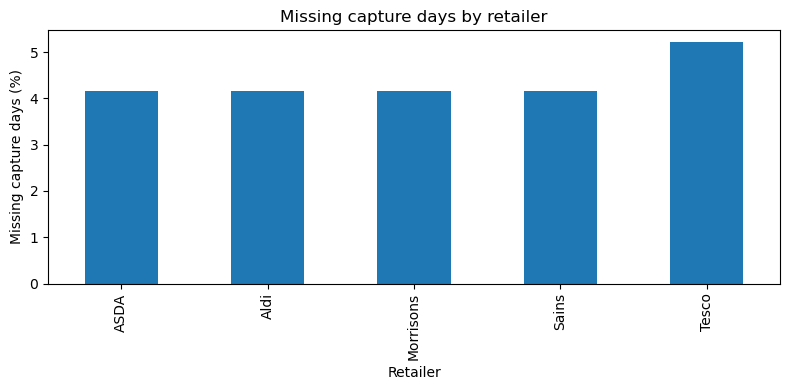

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/figure_hazard_capture_gaps.png


In [45]:
fig, ax = plt.subplots(figsize=(8, 4))

capture_gap_hazard_summary.plot(
    x="retailer",
    y="missing_capture_days_pct",
    kind="bar",
    legend=False,
    ax=ax
)

ax.set_title("Missing capture days by retailer")
ax.set_xlabel("Retailer")
ax.set_ylabel("Missing capture days (%)")

plt.tight_layout()

fig_path = RESULTS_DIR / "figure_hazard_capture_gaps.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

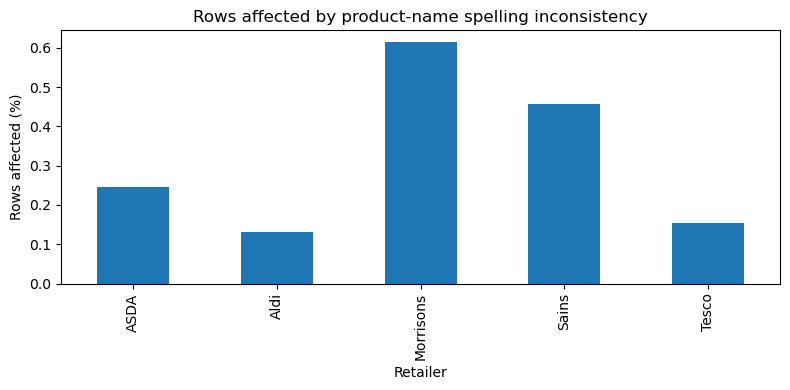

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/figure_hazard_name_spelling.png


In [46]:
fig, ax = plt.subplots(figsize=(8, 4))

spelling_hazard_summary.plot(
    x="retailer_file",
    y="affected_rows_pct",
    kind="bar",
    legend=False,
    ax=ax
)

ax.set_title("Rows affected by product-name spelling inconsistency")
ax.set_xlabel("Retailer")
ax.set_ylabel("Rows affected (%)")

plt.tight_layout()

fig_path = RESULTS_DIR / "figure_hazard_name_spelling.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [47]:
quality_report_summary = pd.DataFrame([
    {
        "hazard": "Duplicate product-retailer-date keys",
        "main_metric": "duplicated_rows_pct",
        "worst_retailer": duplicate_key_summary.sort_values("duplicated_rows_pct", ascending=False).iloc[0]["retailer"],
        "worst_value_pct": duplicate_key_summary["duplicated_rows_pct"].max(),
        "output_table": "hazard_duplicate_key_summary.csv",
        "output_figure": "figure_hazard_duplicate_keys.png"
    },
    {
        "hazard": "Implausible prices",
        "main_metric": "rows_with_any_price_hazard_pct",
        "worst_retailer": price_hazard_summary.sort_values("rows_with_any_price_hazard_pct", ascending=False).iloc[0]["retailer"],
        "worst_value_pct": price_hazard_summary["rows_with_any_price_hazard_pct"].max(),
        "output_table": "hazard_implausible_price_summary.csv",
        "output_figure": "figure_hazard_implausible_prices.png"
    },
    {
        "hazard": "Capture-frequency gaps",
        "main_metric": "missing_capture_days_pct",
        "worst_retailer": capture_gap_hazard_summary.sort_values("missing_capture_days_pct", ascending=False).iloc[0]["retailer"],
        "worst_value_pct": capture_gap_hazard_summary["missing_capture_days_pct"].max(),
        "output_table": "hazard_capture_gap_summary.csv",
        "output_figure": "figure_hazard_capture_gaps.png"
    },
    {
        "hazard": "Inconsistent product-name spelling",
        "main_metric": "affected_rows_pct",
        "worst_retailer": spelling_hazard_summary.sort_values("affected_rows_pct", ascending=False).iloc[0]["retailer_file"],
        "worst_value_pct": spelling_hazard_summary["affected_rows_pct"].max(),
        "output_table": "hazard_name_spelling_summary.csv",
        "output_figure": "figure_hazard_name_spelling.png"
    }
])

quality_report_summary

,hazard,main_metric,worst_retailer,worst_value_pct,output_table,output_figure
0,Duplicate product-retailer-date keys,duplicated_rows_pct,Tesco,2.1529,hazard_duplicate_key_summary.csv,figure_hazard_duplicate_keys.png
1,Implausible prices,rows_with_any_price_hazard_pct,Aldi,2.3723,hazard_implausible_price_summary.csv,figure_hazard_implausible_prices.png
2,Capture-frequency gaps,missing_capture_days_pct,Tesco,5.2083,hazard_capture_gap_summary.csv,figure_hazard_capture_gaps.png
3,Inconsistent product-name spelling,affected_rows_pct,Morrisons,0.6136,hazard_name_spelling_summary.csv,figure_hazard_name_spelling.png


In [48]:
quality_report_summary.to_csv(
    RESULTS_DIR / "data_quality_report_summary.csv",
    index=False
)

print("Saved:", RESULTS_DIR / "data_quality_report_summary.csv")

Saved: /Users/charan/Documents/supermarket-price-direction/results/data_audit/data_quality_report_summary.csv
